In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')

TensorFlow version : 2.20.0
Random seed set to  : 42


In [4]:
RESULTS_DIR = '/content/drive/MyDrive/ME2/results/'
MODEL_DIR   = '/content/drive/MyDrive/ME2/model/'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)
print('Models  will be saved to:', MODEL_DIR)

Results will be saved to: /content/drive/MyDrive/ME2/results/
Models  will be saved to: /content/drive/MyDrive/ME2/model/


In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU.')

GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [6]:
import kagglehub

# Dataset: pacificrm/skindiseasedataset
# Structure: SkinDisease/train/<ClassName>/  and  SkinDisease/test/<ClassName>/
# We only use Warts and Moles from both splits.
path = kagglehub.dataset_download('pacificrm/skindiseasedataset')
print('Path to dataset files:', path)

100%|██████████| 1.36G/1.36G [00:54<00:00, 26.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6


In [7]:
# Walk the top levels to confirm structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 3:
        print('  ' * depth + Path(root).name)

6
  SkinDisease
    SkinDisease
      train
      test


In [8]:
# Locate the Warts and Moles folders inside train/ and test/
# The dataset already has train and test splits, so we use them directly
# and carve out a val set from train (15% of each class).

TARGET_CLASSES = ['Warts', 'Moles']

src_train = {}
src_test  = {}

for dirpath, dirnames, _ in os.walk(path):
    parts = Path(dirpath).parts
    name  = Path(dirpath).name

    # Match case-insensitively
    for cls in TARGET_CLASSES:
        if name.lower() == cls.lower():
            parent = Path(dirpath).parent.name.lower()
            if parent == 'train':
                src_train[cls] = Path(dirpath)
            elif parent == 'test':
                src_test[cls]  = Path(dirpath)

print('Train sources:')
for k, v in src_train.items():
    print(f'  {k}: {v}')
print('Test sources:')
for k, v in src_test.items():
    print(f'  {k}: {v}')

for cls in TARGET_CLASSES:
    assert cls in src_train, f'Could not find {cls} inside train/'
    assert cls in src_test,  f'Could not find {cls} inside test/'

Train sources:
  Moles: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease/SkinDisease/train/Moles
  Warts: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease/SkinDisease/train/Warts
Test sources:
  Moles: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease/SkinDisease/test/Moles
  Warts: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease/SkinDisease/test/Warts


In [9]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

print('Image counts in source folders:')
for cls in TARGET_CLASSES:
    n_tr = count_images(src_train[cls])
    n_te = count_images(src_test[cls])
    print(f'  {cls:<10}  train={n_tr}  test={n_te}')

Image counts in source folders:
  Warts       train=580  test=64
  Moles       train=361  test=40


In [10]:
# Build train / val / test splits:
#   - test  : taken directly from the dataset's test/ folder (no changes)
#   - train : 85% of the dataset's train/ folder  (per class)
#   - val   : 15% of the dataset's train/ folder  (per class)

SPLIT_ROOT = '/content/skin_split'
VAL_RATIO  = 0.15

def build_splits(split_root, src_train, src_test, target_classes, val_ratio, seed=42):
    rng  = random.Random(seed)
    exts = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for split in ('train', 'val', 'test'):
        for cls in target_classes:
            os.makedirs(os.path.join(split_root, split, cls), exist_ok=True)

    for cls in target_classes:
        # ---- test: copy straight from kaggle test folder ----
        test_imgs = [p for p in Path(src_test[cls]).iterdir()
                     if p.is_file() and p.suffix in exts]
        dst_test = os.path.join(split_root, 'test', cls)
        for img in test_imgs:
            shutil.copy2(img, os.path.join(dst_test, img.name))

        # ---- train + val: split kaggle train folder 85/15 ----
        train_imgs = [p for p in Path(src_train[cls]).iterdir()
                      if p.is_file() and p.suffix in exts]
        rng.shuffle(train_imgs)

        n_val   = max(1, int(len(train_imgs) * val_ratio))
        val_imgs   = train_imgs[:n_val]
        train_imgs = train_imgs[n_val:]

        for split_name, imgs in [('train', train_imgs), ('val', val_imgs)]:
            dst = os.path.join(split_root, split_name, cls)
            for img in imgs:
                shutil.copy2(img, os.path.join(dst, img.name))

        print(f'  {cls:<10}  train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}')

if not Path(SPLIT_ROOT).exists():
    print('Building train / val / test split...')
    build_splits(SPLIT_ROOT, src_train, src_test, TARGET_CLASSES, VAL_RATIO, seed=SEED)
    print('Done.')
else:
    print('Split already exists at', SPLIT_ROOT)

Building train / val / test split...
  Warts       train=493  val=87  test=64
  Moles       train=307  val=54  test=40
Done.


In [11]:
# Confirm final counts
for split in ('train', 'val', 'test'):
    split_path = Path(SPLIT_ROOT) / split
    total = count_images(split_path)
    print(f'{split:>5} : {total} total')
    for cls_dir in sorted(split_path.iterdir()):
        print(f'         {cls_dir.name:<12}: {count_images(cls_dir)}')

train : 800 total
         Moles       : 307
         Warts       : 493
  val : 141 total
         Moles       : 54
         Warts       : 87
 test : 104 total
         Moles       : 40
         Warts       : 64


In [12]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


In [13]:
train_dir = Path(SPLIT_ROOT) / 'train'
val_dir   = Path(SPLIT_ROOT) / 'val'
test_dir  = Path(SPLIT_ROOT) / 'test'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=True,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)

Found 800 files belonging to 2 classes.
Found 141 files belonging to 2 classes.
Found 104 files belonging to 2 classes.


In [14]:
class_names = train_dataset.class_names
print(f'Classes: {class_names}')
# Expected: ['Moles', 'Warts']  (alphabetical)

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes, found {len(class_names)}: {class_names}')

Classes: ['Moles', 'Warts']


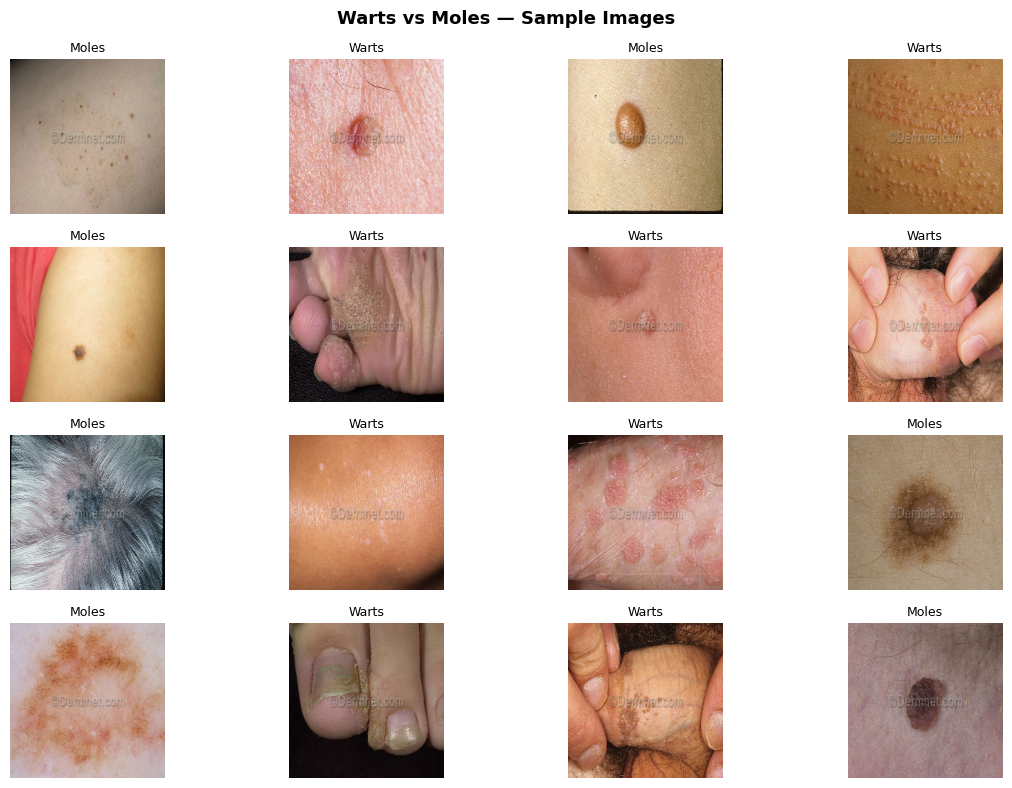

In [15]:
# Visualise a sample batch
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('Warts vs Moles — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


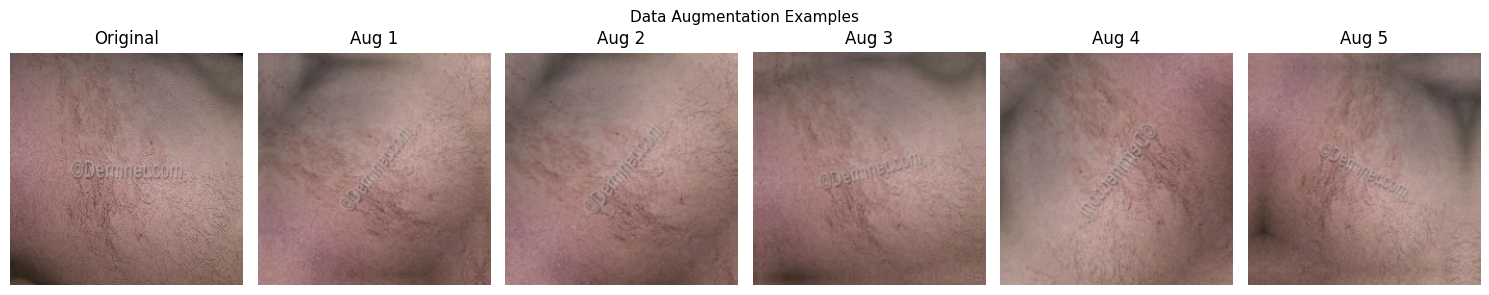

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
def make_callbacks(name, model_dir=MODEL_DIR):
    """Return a fresh set of callbacks for a training run."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Train Accuracy',      linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Train Loss',      linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a binary classification model (sigmoid output, threshold 0.5)."""
    y_true, y_pred, y_prob = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)


print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [19]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    # Freeze the base model for the feature-extraction phase
    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs  = tf.keras.Input(shape=input_shape)
    x       = augmentation(inputs)
    x       = preprocess_fn(x)                    # scale pixels to [-1, 1]
    x       = base_model(x, training=False)        # frozen inference mode
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dense(128, activation='relu')(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_skin'), base_model


tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model      : mobilenetv2_1.00_224
Trainable layers: 0 / 154


Model: "mobilenetv2_skin"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Phase 1 — Feature Extraction (base frozen)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_skin_feature_extraction'),
    verbose=1,
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5008 - loss: 0.8835
Epoch 1: val_accuracy improved from None to 0.68085, saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_feature_extraction_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_feature_extraction_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.5675 - loss: 0.7932 - val_accuracy: 0.6809 - val_loss: 0.5939 - learning_rate: 1.0000e-04
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7054 - loss: 0.5823
Epoch 2: val_accuracy improved from 0.68085 to 0.71631, saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_feature_extraction_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_feature_extraction_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.7212 - loss: 0.5614 - val_accuracy: 0.7163 - val_loss: 0.5236 - learning_rate: 1.0000e-04
Epoch 3/2

MobileNetV2 TL -> val_loss    : 0.3328
MobileNetV2 TL -> val_accuracy: 0.8369


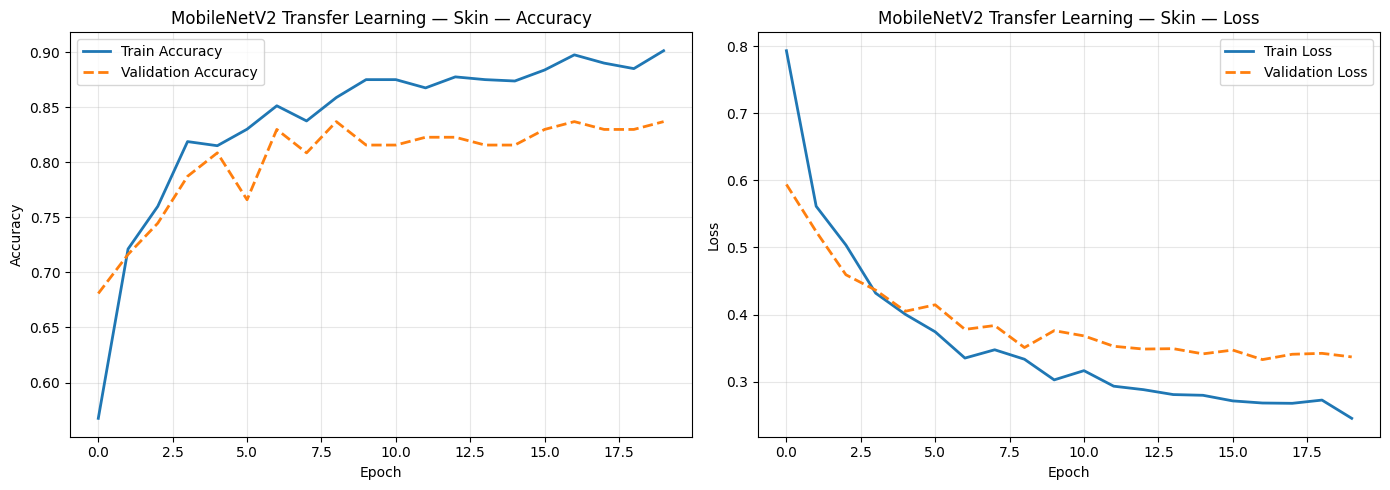

In [21]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss    : {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning — Skin')


MobileNetV2 Transfer — Skin
Accuracy  : 0.8077
Precision : 0.9074
Recall    : 0.7656
F1-Score  : 0.8305

Classification Report:
              precision    recall  f1-score   support

       Moles     0.7000    0.8750    0.7778        40
       Warts     0.9074    0.7656    0.8305        64

    accuracy                         0.8077       104
   macro avg     0.8037    0.8203    0.8041       104
weighted avg     0.8276    0.8077    0.8102       104



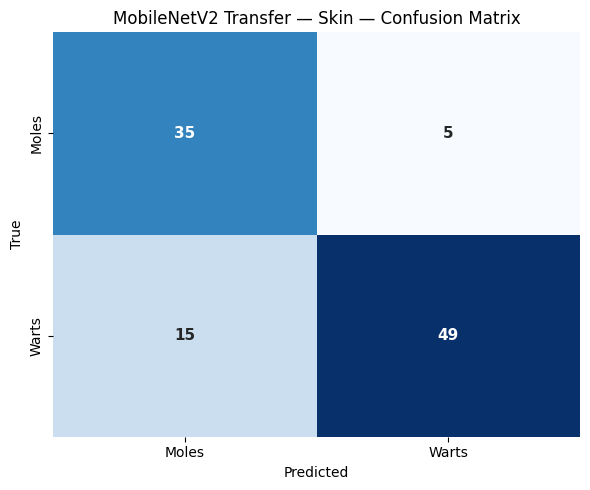

In [22]:
tl_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Transfer — Skin'
)

In [23]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers of the base)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 154


In [24]:
FINETUNE_LR = LR / 10   # 1e-5

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [25]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_skin_finetuned'),
    verbose=1,
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5267 - loss: 0.8883
Epoch 1: val_accuracy improved from None to 0.85106, saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME2/model/mobilenetv2_skin_finetuned_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 213ms/step - accuracy: 0.6550 - loss: 0.6610 - val_accuracy: 0.8511 - val_loss: 0.3287 - learning_rate: 1.0000e-05
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7583 - loss: 0.4861
Epoch 2: val_accuracy did not improve from 0.85106
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7875 - loss: 0.4564 - val_accuracy: 0.8298 - val_loss: 0.3388 - learning_rate: 1.0000e-05
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8717 - loss: 0.3513
Epoch 3: val_accuracy did not improve from 0.85106
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8562 - loss: 0.3594 - val_accuracy: 0.8156 - val_loss

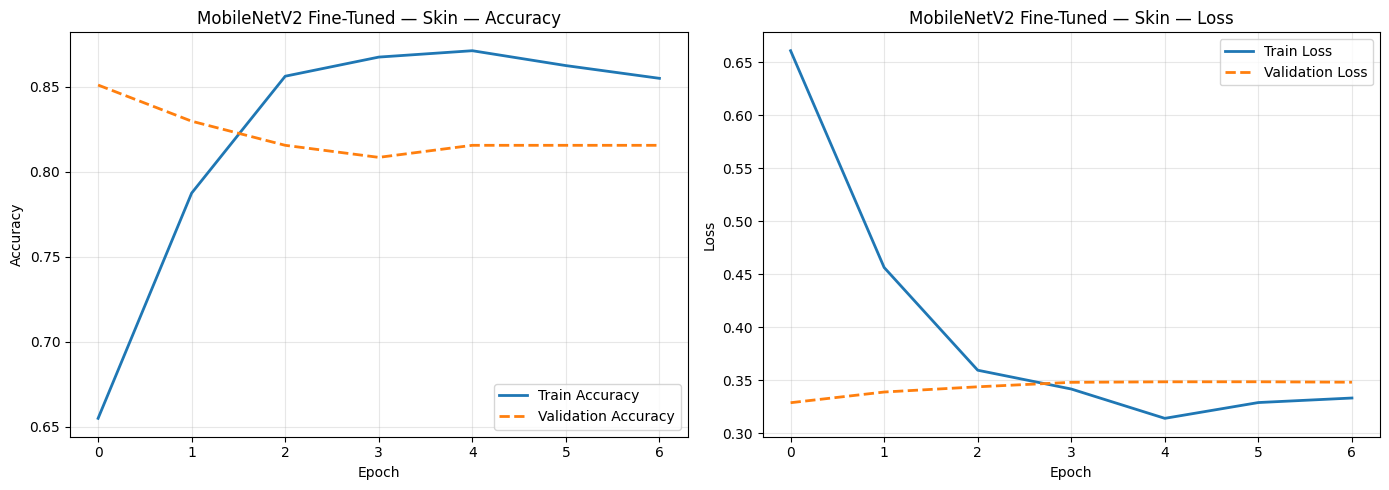


MobileNetV2 Fine-Tuned — Skin
Accuracy  : 0.8077
Precision : 0.9074
Recall    : 0.7656
F1-Score  : 0.8305

Classification Report:
              precision    recall  f1-score   support

       Moles     0.7000    0.8750    0.7778        40
       Warts     0.9074    0.7656    0.8305        64

    accuracy                         0.8077       104
   macro avg     0.8037    0.8203    0.8041       104
weighted avg     0.8276    0.8077    0.8102       104



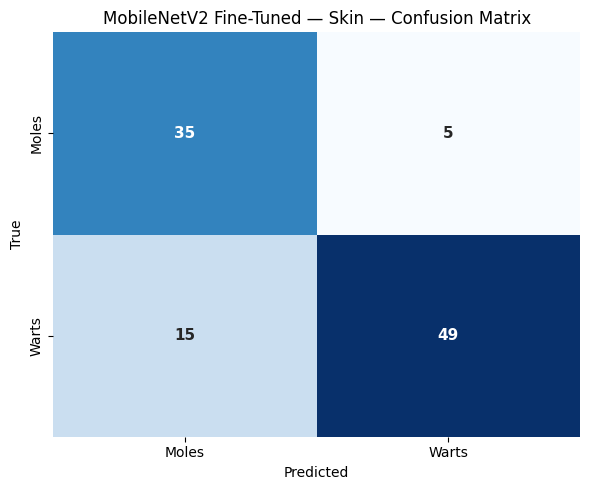


--- Summary ---
Feature-extraction test accuracy : 0.8077
Fine-tuned         test accuracy : 0.8077


In [26]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned — Skin')

ft_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Fine-Tuned — Skin'
)

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned         test accuracy : {ft_test_acc:.4f}')

In [27]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the trained model."""
    img       = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)   # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0)   # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    prob       = model.predict(img_array, verbose=0)[0][0]
    label      = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.4f}')


print('predict_image() utility defined.')
print('Usage: predict_image("/path/to/skin.jpg", tl_model, class_names)')

predict_image() utility defined.
Usage: predict_image("/path/to/skin.jpg", tl_model, class_names)


In [28]:
# Save the final fine-tuned model to Google Drive
FINAL_MODEL_PATH = '/content/drive/MyDrive/ME2/model/skin_warts_moles_model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f'  {FINAL_MODEL_PATH}')
print(f'  Final test accuracy: {ft_test_acc:.4f}')

Model saved:
  /content/drive/MyDrive/ME2/model/skin_warts_moles_model.keras
  Final test accuracy: 0.8077


In [29]:
# ── Generate class_stats.npz for OOD Layer 2 ─────────────────────────────────────────────
# Run this cell ONCE after training.
# We reload val images directly from disk (no augmentation pipeline) so the
# per-class feature statistics are clean and stable — matching what app.py
# sees at inference time.

import numpy as np
import keras

CLASS_STATS_PATH = FINAL_MODEL_PATH.replace(FINAL_MODEL_PATH.split('/')[-1], 'class_stats.npz')

# Load the saved model
saved_model = keras.models.load_model(FINAL_MODEL_PATH)
print('Model loaded from:', FINAL_MODEL_PATH)

# Build feature extractor: model.input → GlobalAveragePooling2D
gap_layer = next(
    l for l in reversed(saved_model.layers)
    if isinstance(l, keras.layers.GlobalAveragePooling2D)
)
feature_extractor = keras.Model(
    inputs=saved_model.input,
    outputs=gap_layer.output,
    name='feature_extractor',
)
print(f'Feature extractor output shape: {feature_extractor.output_shape}')

# Reload val set FRESH from disk (no cache, no augmentation)
# This ensures features match exactly what app.py computes at inference time.
val_dataset_clean = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

# Collect features and labels
all_features, all_labels = [], []
for imgs, lbls in val_dataset_clean:
    feats = feature_extractor(imgs, training=False).numpy()
    all_features.append(feats)
    all_labels.append(lbls.numpy().flatten())

all_features = np.concatenate(all_features, axis=0)  # (N, 1280)
all_labels   = np.concatenate(all_labels,   axis=0)  # (N,)
print(f'Collected {len(all_features)} val samples, feature dim={all_features.shape[1]}')

# Compute per-class mean and std
class_means, class_stds = [], []
for idx, name in enumerate(class_names):
    mask        = all_labels == idx
    class_feats = all_features[mask]
    class_means.append(class_feats.mean(axis=0))
    class_stds.append(class_feats.std(axis=0) + 1e-8)  # avoid div-by-zero
    print(f'  {name}: {mask.sum()} samples')

class_means = np.array(class_means)  # (n_classes, 1280)
class_stds  = np.array(class_stds)   # (n_classes, 1280)

# Save to Drive
np.savez(CLASS_STATS_PATH, means=class_means, stds=class_stds, class_names=class_names)
print(f'\nclass_stats.npz saved to: {CLASS_STATS_PATH}')
print('OOD Layer 2 is now enabled in the Streamlit app.')


Model loaded from: /content/drive/MyDrive/ME2/model/skin_warts_moles_model.keras
Feature extractor output shape: (None, 1280)
Collected 141 val samples, feature dim=1280
  Moles: 54 samples
  Warts: 87 samples

class_stats.npz saved to: /content/drive/MyDrive/ME2/model/class_stats.npz
OOD Layer 2 is now enabled in the Streamlit app.
